# Кузьмичев Никита
## **Домашние задания №10-11**

### Тема: компьютерное зрение в PyTorch.
#### Часть S10: CNN, аугментации, transfer learning на ResNet.
#### Часть S11: детекция или сегментация, корректная визуализация и базовая валидация.

##### **1. Импорты, seed и устройство**

In [1]:
# Включение библиотек:
import os
import json
import math
import time
import random
from typing import Tuple, Dict, List
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
# Для части A
from torchvision import datasets, transforms, models
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights
# Для части B
from torchvision.datasets import OxfordIIITPet
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.transforms import functional as F
from torchvision.transforms import InterpolationMode

print("TorchVers_:", torch.__version__)
print("TorchvisionVers_:", torchvision.__version__)
print("Success!")

TorchVers_: 2.10.0+cu128
TorchvisionVers_: 0.25.0+cu128
Success!


In [2]:
# Установка seed
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

In [3]:
# Определение устройства
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [4]:
# Создание папок:
os.makedirs('artifacts/figures', exist_ok=True)

In [5]:
# Доп параметры
FAST_MODE = False   # переключите на True для частичного датасета и более быстрого обучения
DATA_DIR = "./data"

BATCH_SIZE = 128
EPOCHS = 4 if FAST_MODE else 12

In [6]:
# Решение по смерти ядра при попытке генерации картинок из датасета (блок: 11)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

##### **2. Данные и DataLoader**

In [7]:
# базовые transforms:
# Базовый transform для простой CNN
BASE_MEAN = (0.5, 0.5, 0.5)
BASE_STD = (0.5, 0.5, 0.5)
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(BASE_MEAN, BASE_STD)
])

# transforms с аугментацией
AUG_MEAN = (0.5, 0.5, 0.5)
AUG_TRANSFORM = (0.5, 0.5, 0.5)
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(AUG_MEAN, AUG_TRANSFORM)
])

# preprocessing для ResNet18
RESNET_MEAN = [0.485, 0.456, 0.406]
RESNET_STD = [0.229, 0.224, 0.225]
resnet_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=RESNET_MEAN, std=RESNET_STD)
])

In [8]:
# Загрузка cifar 100
def load_cifar100(data_dir: str = DATA_DIR):
    # download
    full_train_dataset = datasets.CIFAR100(root=DATA_DIR, train=True, download=True, transform=base_transform)
    test_dataset = datasets.CIFAR100(root=DATA_DIR, train=False, download=True, transform=base_transform)
    return full_train_dataset, test_dataset
# Проверка:
full_train_dataset, test_dataset = load_cifar100()
class_names = full_train_dataset.classes
print("Train full:", len(full_train_dataset))
print("Test:", len(test_dataset))
print("Classes:", class_names)

100%|██████████| 169M/169M [00:03<00:00, 49.5MB/s]


Train full: 50000
Test: 10000
Classes: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtl

In [9]:
# разделение на train и val
def make_loaders(
    ds_train_full,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    # train/val split (80/20)
    n_total = len(ds_train_full)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    ds_train, ds_val = random_split(
        ds_train_full,
        lengths=[n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )

    # FAST_MODE: уменьшаем размер для скорости
    if fast_mode:
        # аккуратно: Subset от Subset (random_split возвращает Subset)
        rng = np.random.RandomState(seed)
        train_idx = rng.choice(len(ds_train), size=min(6000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(1500, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(1500, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test_small = Subset(ds_test, test_idx)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

In [10]:
train_loader, val_loader, test_loader = make_loaders(full_train_dataset, test_dataset)

# Проверка (sanity check):
batch = next(iter(train_loader))
x, y = batch
print(f"CIFAR100 Batch: x shape {x.shape}, y shape {y.shape}")
print(f"CIFAR100 Batch: x type {x.dtype}, y type {y.dtype}")

CIFAR100 Batch: x shape torch.Size([128, 3, 32, 32]), y shape torch.Size([128])
CIFAR100 Batch: x type torch.float32, y type torch.int64


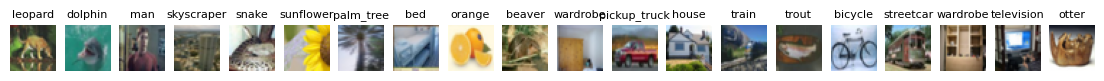

In [11]:
# Визуализация (в ноутбуке изображения хранятся в **нормализированном** виде
## Чтобы их увидеть, необходимо сделать обратную денормализацию)

def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(BASE_MEAN).view(3, 1, 1)
    std = torch.tensor(BASE_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=20)

In [12]:
# Конфигурация для Oxford IIIT Pets
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = True # Рекомендую True для быстрого теста
    n_show: int = 3

cfg = RunConfig()

##### **Статистка на их же сайте:**

**Изображение сдохло ;(**

In [13]:
# Скачиванием данные oxford iiit pets
class OxfordPetSegDataset(torch.utils.data.Dataset):
    def __init__(self, root: str):
        # Автоматически скачиваем и загружаем датасет (нужно подождать при первом запуске)
        self.base_dataset = OxfordIIITPet(
            root=root,
            split="trainval",
            target_types="segmentation",
            download=True
        )

    def __len__(self) -> int:
        return len(self.base_dataset)

    def __getitem__(self, idx: int):
        img_pil, mask_pil = self.base_dataset[idx]

        # В Oxford Pets маски: 1 (pet), 2 (background), 3 (border).
        # Нам нужен только питомец, поэтому берем пиксели == 1
        mask_np = np.array(mask_pil)
        gt = (mask_np == 1).astype(np.uint8)  # [H,W], 0/1

        return img_pil, gt  # img = PIL, gt = numpy

dataset = OxfordPetSegDataset(cfg.data_dir)
print(f"Загружено изображений: {len(dataset)}")

100%|██████████| 792M/792M [00:29<00:00, 27.1MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.0MB/s]


Загружено изображений: 3680


In [14]:
# Тестовый DataLoader для Части B
seg_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

seg_target_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor()
])

pet_dataset = datasets.OxfordIIITPet(root=DATA_DIR, split='trainval', target_types='segmentation',
                                     download=True, transform=seg_transform, target_transform=seg_target_transform)
pet_loader = DataLoader(pet_dataset, batch_size=4, shuffle=True)

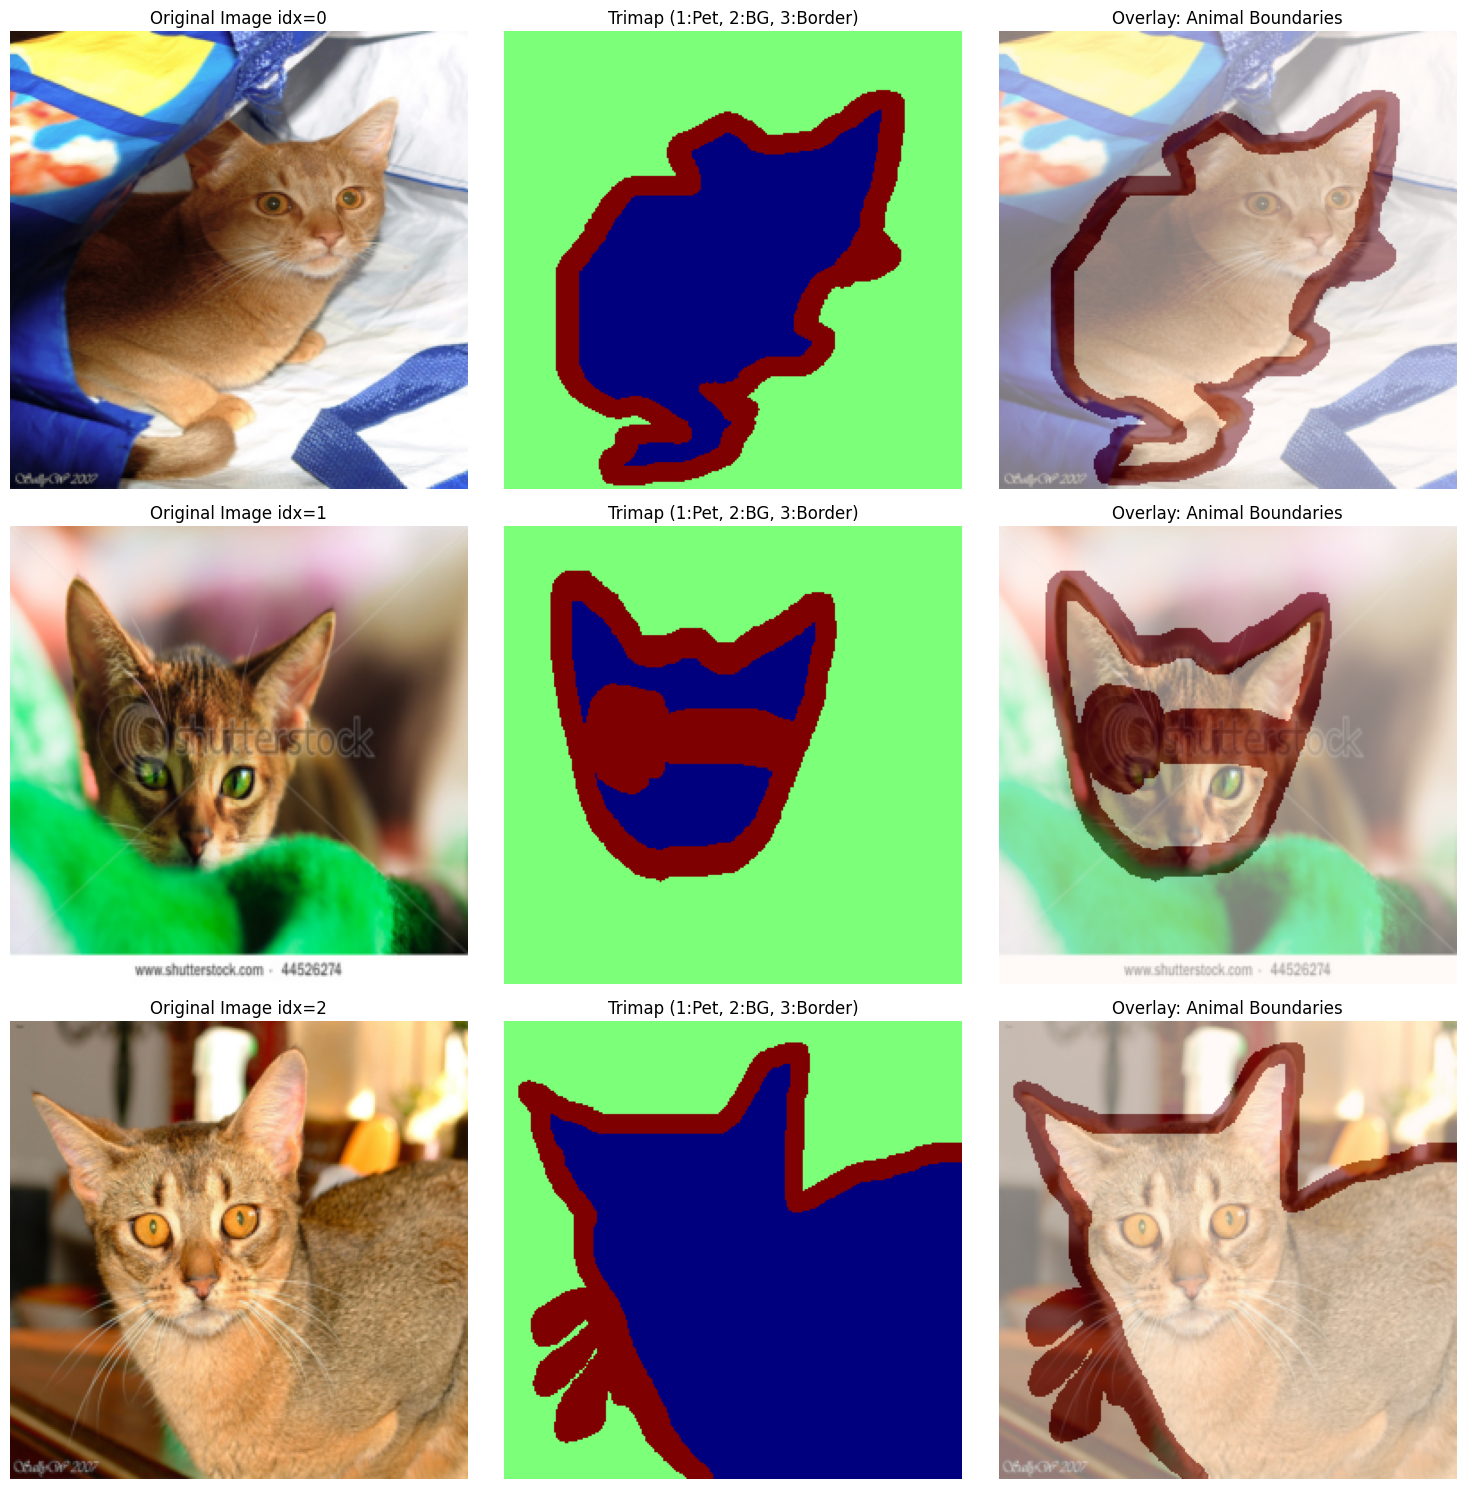

In [15]:
def visualize_pet_segmentation(dataset, n_show=3):
    fig, axes = plt.subplots(n_show, 3, figsize=(15, 5 * n_show))

    for i in range(n_show):
        img_t, mask_t = dataset[i]

        # Подготовка изображения для plt (из [C, H, W] в [H, W, C])
        img_np = img_t.permute(1, 2, 0).numpy()

        # Маска в Oxford Pets приходит в значениях (1/255, 2/255, 3/255) после ToTensor
        # Умножим на 255, чтобы получить чистые индексы 1, 2, 3
        mask_np = (mask_t.squeeze().numpy() * 255).astype(np.uint8)

        # Создаем цветную визуализацию для маски:
        # Питомец (1) - Желтый, Фон (2) - Фиолетовый, Граница (3) - Красный
        # Это поможет нам увидеть именно границы

        # Визуализация 1: Оригинал
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f"Original Image idx={i}")
        axes[i, 0].axis("off")

        # Визуализация 2: Маска (Trimap)
        # Мы используем cmap='viridis' или 'jet', чтобы разные классы (1, 2, 3) были разного цвета
        axes[i, 1].imshow(mask_np, cmap='jet')
        axes[i, 1].set_title("Trimap (1:Pet, 2:BG, 3:Border)")
        axes[i, 1].axis("off")

        # Визуализация 3: Наложение границ на оригинал
        # Выделим только границы (класс 3)
        border_mask = (mask_np == 3).astype(float)

        axes[i, 2].imshow(img_np)
        # Накладываем только границы красным цветом с прозрачностью
        axes[i, 2].imshow(border_mask, alpha=0.5, cmap='Reds')
        axes[i, 2].set_title("Overlay: Animal Boundaries")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

# Запуск
visualize_pet_segmentation(pet_dataset, n_show=3)

##### **3. Базовые функции обучения и оценки**

In [16]:
import copy
import csv
from torchvision.models import resnet18, ResNet18_Weights
from scipy import ndimage

In [17]:
# Для части A:

In [18]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

In [19]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

In [20]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

In [21]:
def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

In [22]:
def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

In [23]:
def log_run(ex_id, task, dataset, model, optimizer, lr, epochs, best_val_acc, test_acc, notes="", precision = None, recall = None, mean_iou = None):
    run_info = {
        "experiment_id": ex_id,
        "task": task,
        "dataset": dataset,
        "seed": RANDOM_STATE,
        "model_summary": model.__class__.__name__ if type(model) != type(str()) else model,
        "optimizer": optimizer.__class__.__name__ if type(optimizer) != type(None) else optimizer,
        "lr": lr,
        "epochs_trained": epochs,
        "best_val_accuracy": round(best_val_acc, 4) if best_val_acc is not None else None,
        "test_accuracy": round(test_acc, 4) if test_acc is not None else None,
        "precision": precision,
        "recall": recall,
        "mean_iou": mean_iou,
        "notes": notes
    }
    all_runs.append(run_info)

In [24]:
# Начало экспериментов C1-C4

In [25]:
INPUT_DIM = 32 * 32 * 3
NUM_CLASSES = 100
CRITERION = nn.CrossEntropyLoss()
LR = 1e-3

all_runs = []

In [26]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [27]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32 -> 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16x16 -> 16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 8x8 -> 8x8
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=100, bias=True)
  )
)
Trainable params: 643492


In [28]:
# Подготовка данных для разных экспериментов
def train_cifar100(TRF_TYPE, data_dir: str = DATA_DIR):
    # download
    full_train_dataset = datasets.CIFAR100(root=DATA_DIR, train=True, download=True, transform=TRF_TYPE)
    test_dataset = datasets.CIFAR100(root=DATA_DIR, train=False, download=True, transform=TRF_TYPE)
    return full_train_dataset, test_dataset

full_train_base, test_base = train_cifar100(base_transform)
full_train_aug, test_aug = train_cifar100(aug_transform)
full_train_res, test_res = train_cifar100(resnet_transform)

train_loader_c1, val_loader_c1, _ = make_loaders(full_train_base, test_base)
train_loader_c2, val_loader_c2, _ = make_loaders(full_train_aug, test_aug) # test тот же
train_loader_res, val_loader_res, test_loader_res = make_loaders(full_train_res, test_res)

In [29]:
# --- Эксперимент C1: Simple CNN (Base) ---
print("\n>>> Running C1 (simple-cnn-base)...")
set_seed(RANDOM_STATE)
model_c1 = SimpleCNN(num_classes=NUM_CLASSES).to(DEVICE)
opt_c1 = optim.Adam(model_c1.parameters(), lr=LR)
hist_c1 = fit(model_c1, train_loader_c1, val_loader_c1, opt_c1, CRITERION, epochs=EPOCHS)
best_val_acc_c1 = max(hist_c1["val_acc"])
log_run("C1", "classification", "CIFAR100", model_c1, opt_c1, LR, EPOCHS, best_val_acc_c1, None, "No augmentations")


>>> Running C1 (simple-cnn-base)...
Epoch 01/12 | train loss 3.8563, acc 0.113 | val loss 3.3374, acc 0.198 | 13.7s
Epoch 02/12 | train loss 3.0922, acc 0.240 | val loss 2.9695, acc 0.263 | 12.3s
Epoch 03/12 | train loss 2.7137, acc 0.317 | val loss 2.7057, acc 0.310 | 12.2s
Epoch 04/12 | train loss 2.4374, acc 0.374 | val loss 2.6044, acc 0.345 | 12.2s
Epoch 05/12 | train loss 2.2212, acc 0.421 | val loss 2.5346, acc 0.357 | 12.3s
Epoch 06/12 | train loss 2.0206, acc 0.463 | val loss 2.4521, acc 0.384 | 12.3s
Epoch 07/12 | train loss 1.8397, acc 0.506 | val loss 2.4546, acc 0.389 | 12.4s
Epoch 08/12 | train loss 1.6642, acc 0.548 | val loss 2.5486, acc 0.383 | 12.3s
Epoch 09/12 | train loss 1.5093, acc 0.583 | val loss 2.5138, acc 0.399 | 12.2s
Epoch 10/12 | train loss 1.3456, acc 0.624 | val loss 2.6644, acc 0.391 | 12.3s
Epoch 11/12 | train loss 1.2000, acc 0.659 | val loss 2.8054, acc 0.393 | 12.1s
Epoch 12/12 | train loss 1.0534, acc 0.697 | val loss 2.9176, acc 0.388 | 12.2s


In [30]:
# --- Эксперимент C2: Simple CNN (Augmented) ---
print("\n>>> Running C2 (simple-cnn-aug)...")
set_seed(RANDOM_STATE)
model_c2 = SimpleCNN(num_classes=NUM_CLASSES).to(DEVICE)
opt_c2 = optim.Adam(model_c2.parameters(), lr=LR)
hist_c2 = fit(model_c2, train_loader_c2, val_loader_c2, opt_c2, CRITERION, epochs=EPOCHS)
best_val_acc_c2 = max(hist_c2["val_acc"])
log_run("C2", "classification", "CIFAR100", model_c2, opt_c2, LR, EPOCHS, best_val_acc_c2, None, "With augmentations")


>>> Running C2 (simple-cnn-aug)...
Epoch 01/12 | train loss 4.0291, acc 0.080 | val loss 3.6258, acc 0.141 | 17.2s
Epoch 02/12 | train loss 3.4181, acc 0.177 | val loss 3.2467, acc 0.206 | 17.3s
Epoch 03/12 | train loss 3.1173, acc 0.231 | val loss 3.0819, acc 0.236 | 18.3s
Epoch 04/12 | train loss 2.9235, acc 0.271 | val loss 2.9031, acc 0.279 | 17.3s
Epoch 05/12 | train loss 2.7811, acc 0.298 | val loss 2.7932, acc 0.304 | 17.1s
Epoch 06/12 | train loss 2.6586, acc 0.324 | val loss 2.6988, acc 0.321 | 17.9s
Epoch 07/12 | train loss 2.5687, acc 0.342 | val loss 2.6386, acc 0.333 | 17.1s
Epoch 08/12 | train loss 2.4731, acc 0.361 | val loss 2.5940, acc 0.339 | 16.9s
Epoch 09/12 | train loss 2.4151, acc 0.373 | val loss 2.5324, acc 0.353 | 18.0s
Epoch 10/12 | train loss 2.3311, acc 0.391 | val loss 2.4961, acc 0.361 | 16.9s
Epoch 11/12 | train loss 2.2753, acc 0.403 | val loss 2.4535, acc 0.370 | 16.8s
Epoch 12/12 | train loss 2.2290, acc 0.414 | val loss 2.4506, acc 0.375 | 18.1s


In [31]:
# --- Эксперимент C3: ResNet18 (Head Only) ---
print("\n>>> Running C3 (resnet18-head-only)...")
set_seed(RANDOM_STATE)
model_c3 = resnet18(weights=ResNet18_Weights.DEFAULT)
# Замораживаем backbone
for param in model_c3.parameters():
    param.requires_grad = False
# Меняем голову
model_c3.fc = nn.Linear(model_c3.fc.in_features, NUM_CLASSES)
model_c3 = model_c3.to(DEVICE)
opt_c3 = optim.Adam(model_c3.fc.parameters(), lr=LR)
hist_c3 = fit(model_c3, train_loader_res, val_loader_res, opt_c3, CRITERION, epochs=EPOCHS)
best_val_acc_c3 = max(hist_c3["val_acc"])
log_run("C3", "classification", "CIFAR100", model_c3, opt_c3, LR, EPOCHS, best_val_acc_c3, None, "Pretrained, backbone frozen")


>>> Running C3 (resnet18-head-only)...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 79.7MB/s]


Epoch 01/12 | train loss 2.7458, acc 0.374 | val loss 1.9400, acc 0.513 | 90.7s
Epoch 02/12 | train loss 1.7392, acc 0.556 | val loss 1.6650, acc 0.554 | 89.7s
Epoch 03/12 | train loss 1.5364, acc 0.591 | val loss 1.5873, acc 0.570 | 88.3s
Epoch 04/12 | train loss 1.4334, acc 0.610 | val loss 1.5422, acc 0.570 | 90.9s
Epoch 05/12 | train loss 1.3670, acc 0.625 | val loss 1.5181, acc 0.578 | 90.0s
Epoch 06/12 | train loss 1.3131, acc 0.635 | val loss 1.5148, acc 0.576 | 90.3s
Epoch 07/12 | train loss 1.2793, acc 0.645 | val loss 1.4915, acc 0.579 | 89.9s
Epoch 08/12 | train loss 1.2502, acc 0.650 | val loss 1.4914, acc 0.584 | 89.7s
Epoch 09/12 | train loss 1.2194, acc 0.659 | val loss 1.5025, acc 0.583 | 90.6s
Epoch 10/12 | train loss 1.1961, acc 0.664 | val loss 1.4998, acc 0.585 | 89.1s
Epoch 11/12 | train loss 1.1719, acc 0.669 | val loss 1.4922, acc 0.582 | 89.6s
Epoch 12/12 | train loss 1.1573, acc 0.672 | val loss 1.5082, acc 0.580 | 89.6s


In [32]:
# --- Эксперимент C4: ResNet18 (Fine-tune layer4 + fc) ---
print("\n>>> Running C4 (resnet18-finetune)...")
set_seed(RANDOM_STATE)
model_c4 = resnet18(weights=ResNet18_Weights.DEFAULT)
model_c4.fc = nn.Linear(model_c4.fc.in_features, NUM_CLASSES)
# Замораживаем всё, кроме layer4 и fc
for name, param in model_c4.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

model_c4 = model_c4.to(DEVICE)
opt_c4 = optim.Adam(filter(lambda p: p.requires_grad, model_c4.parameters()), lr=LR/10) # Снижаем LR для FT
hist_c4 = fit(model_c4, train_loader_res, val_loader_res, opt_c4, CRITERION, epochs=EPOCHS)
best_val_acc_c4 = max(hist_c4["val_acc"])
log_run("C4", "classification", "CIFAR100", model_c4, opt_c4, LR/10, EPOCHS, best_val_acc_c4, None, "Fine-tune layer4 + fc")


>>> Running C4 (resnet18-finetune)...
Epoch 01/12 | train loss 2.3836, acc 0.469 | val loss 1.4769, acc 0.633 | 92.1s
Epoch 02/12 | train loss 1.1507, acc 0.715 | val loss 1.1619, acc 0.685 | 93.2s
Epoch 03/12 | train loss 0.7199, acc 0.826 | val loss 1.0590, acc 0.708 | 95.2s
Epoch 04/12 | train loss 0.4134, acc 0.917 | val loss 1.0067, acc 0.713 | 94.7s
Epoch 05/12 | train loss 0.2008, acc 0.976 | val loss 1.0057, acc 0.715 | 93.7s
Epoch 06/12 | train loss 0.0880, acc 0.996 | val loss 1.0221, acc 0.715 | 93.9s
Epoch 07/12 | train loss 0.0422, acc 0.999 | val loss 1.0088, acc 0.721 | 93.6s
Epoch 08/12 | train loss 0.0247, acc 1.000 | val loss 1.0203, acc 0.721 | 93.6s
Epoch 09/12 | train loss 0.0159, acc 1.000 | val loss 1.0276, acc 0.722 | 94.6s
Epoch 10/12 | train loss 0.0115, acc 1.000 | val loss 1.0464, acc 0.716 | 94.3s
Epoch 11/12 | train loss 0.0087, acc 1.000 | val loss 1.0609, acc 0.716 | 99.5s
Epoch 12/12 | train loss 0.0070, acc 1.000 | val loss 1.0572, acc 0.720 | 96.9s


In [33]:
# Выбор лучшей модели и финальный тест
histories = {"C1": hist_c1, "C2": hist_c2, "C3": hist_c3, "C4": hist_c4}
models_dict = {"C1": model_c1, "C2": model_c2, "C3": model_c3, "C4": model_c4}
best_id = max(histories, key=lambda k: max(histories[k]["val_acc"]))
best_model = models_dict[best_id]

print(f"\nBest model: {best_id} with Val Acc: {max(histories[best_id]['val_acc']):.4f}")


Best model: C4 with Val Acc: 0.7222


In [34]:
# Финальная оценка на тесте (один раз)
# Если лучшая модель - ResNet, используем resnet_loader, иначе test_loader от SimpleCNN
current_test_loader = test_loader_res if "resnet" in best_id.lower() or best_id in ["C3", "C4"] else test_loader
final_test_loss, final_test_acc = evaluate(best_model, current_test_loader, CRITERION)
print(f"Final Test Accuracy for {best_id}: {final_test_acc:.4f}")

# Обновляем test_accuracy в логах для лучшей модели
for run in all_runs:
    if run["experiment_id"] == best_id:
        run["test_accuracy"] = round(final_test_acc, 4)

Final Test Accuracy for C4: 0.7170


In [35]:
# Для части B

In [36]:
# Модель: DeepLabV3 (COCO-with-VOC-labels) + поиск индексов "cat" и "dog"
weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet50(weights=weights)
model.to(DEVICE)
model.eval()

categories = weights.meta.get("categories", None)
if categories is None or "cat" not in categories or "dog" not in categories:
    raise RuntimeError("Проблема с категориями весов модели.")

CAT_IDX = categories.index("cat")
DOG_IDX = categories.index("dog")
print(f"Индекс 'cat': {CAT_IDX}, Индекс 'dog': {DOG_IDX}")

preprocess = weights.transforms()

# проверка
print("Трансформации:\n", preprocess)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 197MB/s]


Индекс 'cat': 8, Индекс 'dog': 12
Трансформации:
 SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [37]:
# Инференс + IoU
@torch.no_grad()
def predict_pet_mask(img_pil: Image.Image) -> torch.Tensor:
    '''
    Возвращает бинарную маску (H,W) для классов cat/dog в пространстве модели.
    '''
    x = preprocess(img_pil).unsqueeze(0).to(DEVICE)  # [1,3,H,W]
    out = model(x)["out"][0]  # [C,H,W]
    pred = out.argmax(0)      # [H,W]

    # Питомец — это либо кошка, либо собака
    pet_mask = ((pred == int(CAT_IDX)) | (pred == int(DOG_IDX))).to(torch.uint8)
    return pet_mask.cpu(), x.shape[-2:]  # (mask, (H,W))

def iou_binary(pred: torch.Tensor, gt: torch.Tensor) -> float:
    pred = pred.bool()
    gt = gt.bool()
    inter = (pred & gt).sum().item()
    union = (pred | gt).sum().item()
    return float(inter / (union + 1e-9))

def eval_subset(indices: List[int]) -> Dict[str, float]:
    ious = []
    for idx in indices:
        img_pil, gt_np = dataset[idx]
        pred_mask, (h, w) = predict_pet_mask(img_pil)

        # resize GT to model space (nearest!)
        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

        ious.append(iou_binary(pred_mask, gt_mask))

    return {
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)),
        "median_IoU": float(np.median(ious)),
    }

if cfg.fast_mode:
    eval_indices = list(range(min(20, len(dataset))))
else:
    eval_indices = list(range(len(dataset)))

metrics = eval_subset(eval_indices)
print("Метрики:\n", metrics)

Метрики:
 {'n': 20.0, 'mean_IoU': 0.7658487437477001, 'median_IoU': 0.7820595338715303}


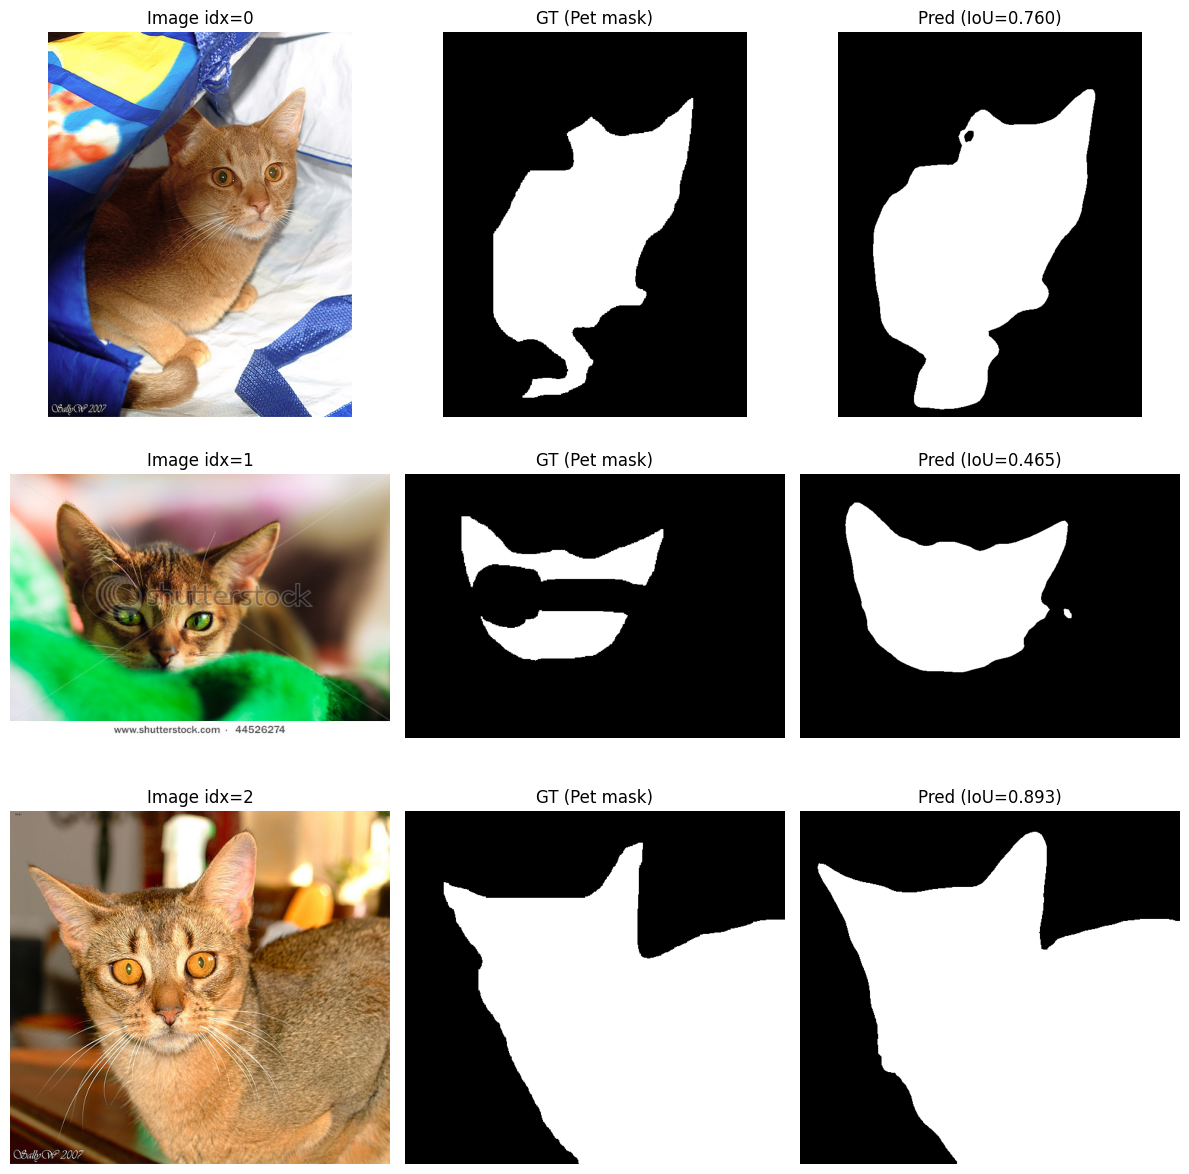

In [38]:
# Визуализация: image / GT / pred
n = min(cfg.n_show, len(dataset))
fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n):
    img_pil, gt_np = dataset[row]
    pred_mask, (h, w) = predict_pet_mask(img_pil)

    # GT resize to model space
    gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
    gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
    gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

    iou = iou_binary(pred_mask, gt_mask)

    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title(f"Image idx={row}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(gt_mask.numpy(), cmap="gray")
    axes[row, 1].set_title("GT (Pet mask)")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pred_mask.numpy(), cmap="gray")
    axes[row, 2].set_title(f"Pred (IoU={iou:.3f})")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [39]:
# Расширенные метрики
def calculate_metrics(pred: torch.Tensor, gt: torch.Tensor):
    pred = pred.bool()
    gt = gt.bool()

    tp = (pred & gt).sum().item()
    fp = (pred & ~gt).sum().item()
    fn = (~pred & gt).sum().item()
    tn = (~pred & ~gt).sum().item()

    iou = tp / (tp + fp + fn + 1e-9)
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)

    return iou, precision, recall

In [40]:
# Функции постобработки
def postprocess_v1(mask_np):
    """Базовая маска (без изменений)"""
    return mask_np

def postprocess_v2(mask_np):
    """Альтернативная обработка: морфологическая очистка"""
    # Заполнение дыр внутри маски
    mask_filled = ndimage.binary_fill_holes(mask_np)
    # Удаление мелких объектов (шума)
    mask_cleaned = ndimage.binary_opening(mask_filled, structure=np.ones((5,5)))
    return mask_cleaned.astype(np.uint8)

In [41]:
def run_segmentation_experiment(exp_id, postprocess_fn, indices):
    all_metrics = {"iou": [], "prec": [], "rec": []}
    examples = [] # Для визуализации

    for idx in indices:
        img_pil, gt_np = dataset[idx]
        # Получаем сырую маску от модели
        raw_mask, (h, w) = predict_pet_mask(img_pil)
        raw_mask_np = raw_mask.numpy()

        # Применяем выбранную постобработку
        processed_mask_np = postprocess_fn(raw_mask_np)
        processed_mask = torch.from_numpy(processed_mask_np)

        # Подготовка GT
        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

        # Считаем метрики
        iou, prec, rec = calculate_metrics(processed_mask, gt_mask)
        all_metrics["iou"].append(iou)
        all_metrics["prec"].append(prec)
        all_metrics["rec"].append(rec)

        if len(examples) < cfg.n_show:
            examples.append({
                "img": img_pil,
                "gt": gt_mask.numpy(),
                "pred": processed_mask_np,
                "iou": iou
            })

    mean_iou = np.mean(all_metrics["iou"])
    mean_prec = np.mean(all_metrics["prec"])
    mean_rec = np.mean(all_metrics["rec"])

    log_run(exp_id, "segmentation", "OxfordIIITPet", "DeepLabV3_ResNet50", None, None, None, None, None,
           "Base processing" if exp_id == "V1" else "Morphological cleaning", round(mean_prec, 4), round(mean_rec, 4), round(mean_iou, 4))

    return mean_iou, examples

In [42]:
# Запуск экспериментов V1, V2

In [43]:
print("Evaluating V1...")
m_iou_v1, examples_v1 = run_segmentation_experiment("V1", postprocess_v1, eval_indices)
m_iou_v1

Evaluating V1...


np.float64(0.7658487437477001)

In [44]:
print("Evaluating V2...")
m_iou_v2, examples_v2 = run_segmentation_experiment("V2", postprocess_v2, eval_indices)
m_iou_v2

Evaluating V2...


np.float64(0.7660606554922782)

In [45]:
pd.DataFrame(all_runs)

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,CIFAR100,42,SimpleCNN,Adam,0.0010,12.0,0.3992,NaN,NaN,NaN,NaN,No augmentations
1,C2,classification,CIFAR100,42,SimpleCNN,Adam,0.0010,12.0,0.3754,NaN,NaN,NaN,NaN,With augmentations
2,C3,classification,CIFAR100,42,ResNet,Adam,0.0010,12.0,0.5853,NaN,NaN,NaN,NaN,"Pretrained, backbone frozen"
3,C4,classification,CIFAR100,42,ResNet,Adam,0.0001,12.0,0.7222,0.717,NaN,NaN,NaN,Fine-tune layer4 + fc
4,V1,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50,None,NaN,NaN,NaN,NaN,0.7856,0.9708,0.7658,Base processing
5,V2,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50,None,NaN,NaN,NaN,NaN,0.7856,0.9711,0.7661,Morphological cleaning


##### **4. Артефакты**

In [46]:
# 1. Сохранение runs.csv
df_runs = pd.DataFrame(all_runs)
df_runs.to_csv('artifacts/runs.csv', index=False)

In [47]:
# ТОЛЬКО для части A

In [48]:
# 2. Сохранение лучшей модели
torch.save(best_model.state_dict(), 'artifacts/best_classifier.pt')

In [49]:
# 3. Сохранение конфигурации лучшей модели
best_config = {
    "experiment_id": best_id,
    "dataset": "CIFAR100",
    "architecture": best_model.__class__.__name__,
    "num_epochs": EPOCHS,
    "lr": LR if best_id != "C4" else LR/10,
    "seed": RANDOM_STATE,
    "transforms": "resnet_transform" if "C3" in best_id or "C4" in best_id else "base/aug_transform"
}
with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(best_config, f, indent=4)

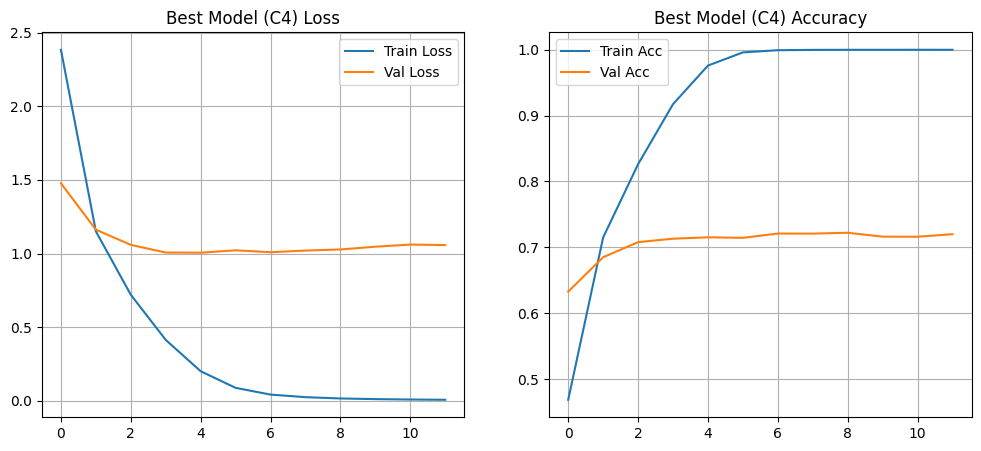

In [50]:
# 4. График обучения лучшей модели (classification_curves_best.png)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(histories[best_id]["train_loss"], label='Train Loss')
plt.plot(histories[best_id]["val_loss"], label='Val Loss')
plt.title(f'Best Model ({best_id}) Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(histories[best_id]["train_acc"], label='Train Acc')
plt.plot(histories[best_id]["val_acc"], label='Val Acc')
plt.title(f'Best Model ({best_id}) Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/classification_curves_best.png')
plt.show()

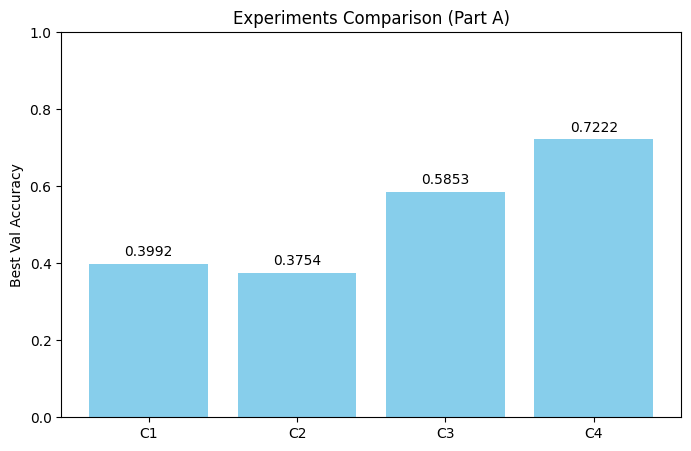

In [51]:
# 5. Сравнение C1-C4 (classification_compare.png)
plt.figure(figsize=(8, 5))
ids = [run["experiment_id"] for run in all_runs if run["experiment_id"].startswith("C")]
accs = [run["best_val_accuracy"] for run in all_runs if run["experiment_id"].startswith("C")]
plt.bar(ids, accs, color='skyblue')
plt.ylabel('Best Val Accuracy')
plt.title('Experiments Comparison (Part A)')
plt.ylim(0, 1.0)
for i, v in enumerate(accs):
    plt.text(i, v + 0.02, str(v), ha = "center")
plt.savefig('artifacts/figures/classification_compare.png')
plt.show()

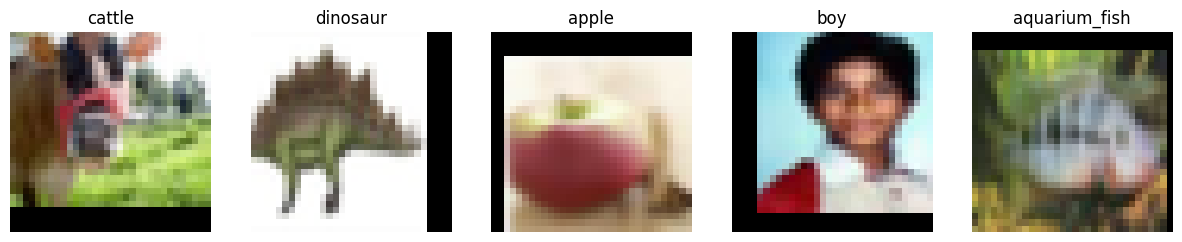

All artifacts saved successfully!


In [52]:
# 6. Визуализация аугментаций (augmentations_preview.png)
def visualize_aug(dataset, n=5):
    plt.figure(figsize=(15, 3))
    for i in range(n):
        img, label = dataset[i]
        # Денормализация для корректного отображения
        img = img * 0.5 + 0.5
        plt.subplot(1, n, i+1)
        plt.imshow(img.permute(1, 2, 0).numpy().clip(0, 1))
        plt.title(class_names[label])
        plt.axis('off')
    plt.savefig('artifacts/figures/augmentations_preview.png')
    plt.show()

# Используем датасет с аугментациями для превью
visualize_aug(full_train_aug)

print("All artifacts saved successfully!")

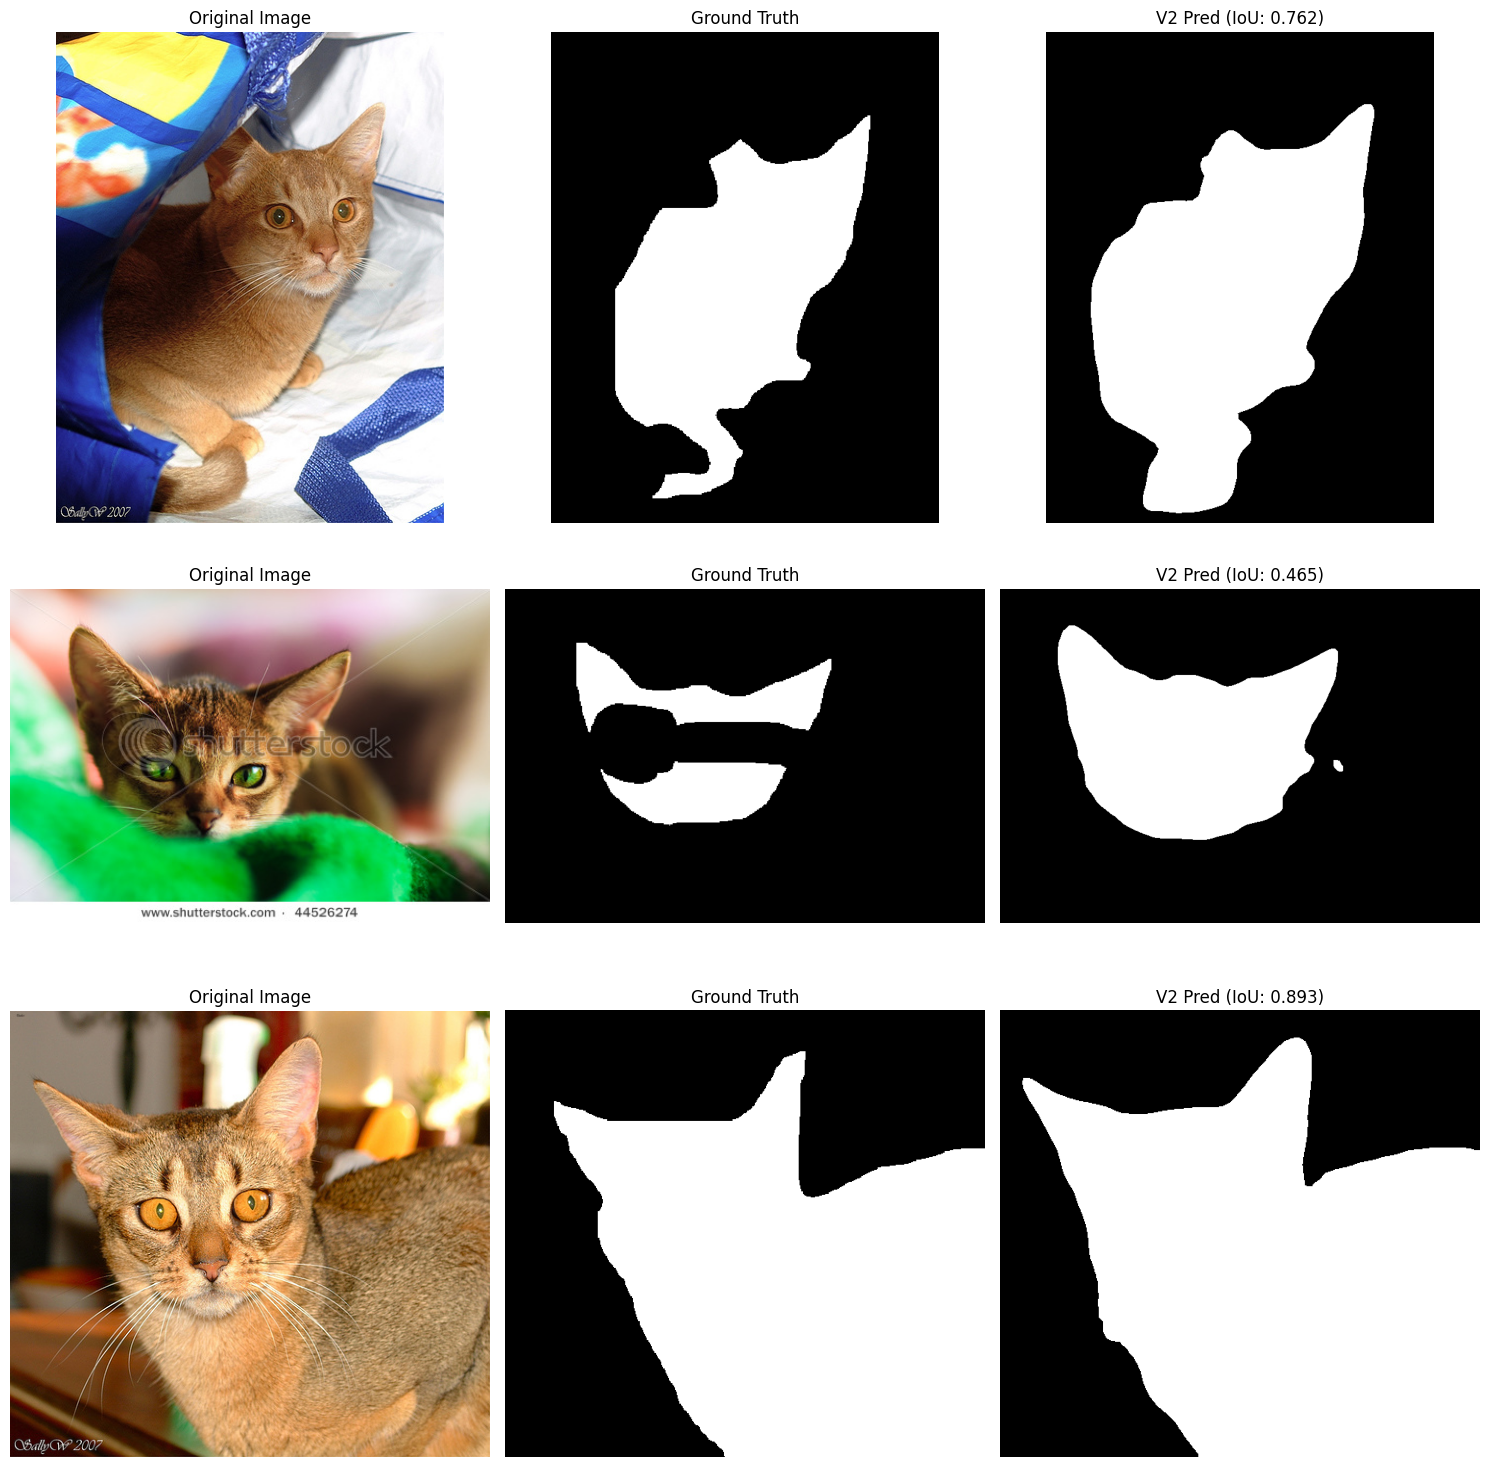

In [53]:
# 7. 1 Визуализация примеров (segmentation_examples.png)
n = cfg.n_show
fig, axes = plt.subplots(n, 3, figsize=(15, 5*n))
for i in range(n):
    ex = examples_v2[i] # Показываем результаты V2 как наиболее интересные
    axes[i, 0].imshow(ex["img"])
    axes[i, 0].set_title("Original Image")
    axes[i, 1].imshow(ex["gt"], cmap='gray')
    axes[i, 1].set_title("Ground Truth")
    axes[i, 2].imshow(ex["pred"], cmap='gray')
    axes[i, 2].set_title(f"V2 Pred (IoU: {ex['iou']:.3f})")
    for ax in axes[i]: ax.axis('off')

plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_examples.png')
plt.show()

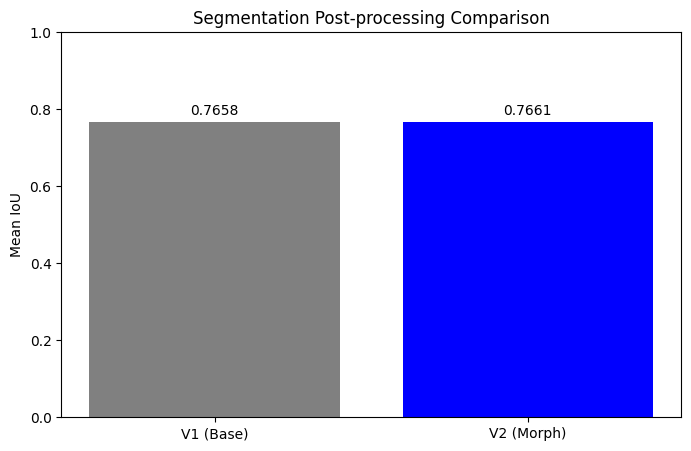

In [54]:
# 7. 2 Сравнение метрик (segmentation_metrics.png)
plt.figure(figsize=(8, 5))
v_ids = ["V1 (Base)", "V2 (Morph)"]
v_ious = [all_runs[-2]["mean_iou"], all_runs[-1]["mean_iou"]]
plt.bar(v_ids, v_ious, color=['gray', 'blue'])
plt.ylabel('Mean IoU')
plt.title('Segmentation Post-processing Comparison')
plt.ylim(0, 1.0)
for i, v in enumerate(v_ious):
    plt.text(i, v + 0.02, str(v), ha='center')
plt.savefig('artifacts/figures/segmentation_metrics.png')
plt.show()